# Phase 2 — Final Modeling, Walk-Forward Testing & FIGS Notebook

This notebook implements the TA-requested **game-by-game prequential evaluation**: train on the two prior complete seasons, predict the next 2020/21 match, observe the result, refit, then predict the following match. The final test sequence is never used for feature/model selection.

In [1]:
from pathlib import Path
import sys, json, pandas as pd, numpy as np
from IPython.display import display, Image

HERE = Path.cwd().resolve()
ROOT = next((p for p in [HERE, *HERE.parents] if (p / "phase1").exists() and (p / "phase2").exists()), None)
if ROOT is None:
    raise RuntimeError("Run this notebook from inside the extracted project folder.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print("Project root:", ROOT)

Project root: D:\arshad\term2\MachinLearning\fainalProject\ML_final\ml_final_work


In [2]:
if not (ROOT / "phase1" / "outputs" / "pre_match_features_final.csv").exists():
    from phase1.final_feature_engineering import run as run_phase1
    run_phase1(ROOT)
from phase2.final_defense_pipeline import run
result = run(ROOT)
print("Phase 2 final pipeline completed.")

c:\Users\Dolphin_Computer\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\kernel_approximation.py:1020: UserWarning: n_components > n_samples. This is not possible.
n_components was set to n_samples, which results in inefficient evaluation of the full kernel.
  warnings.warn(


Phase 2 final pipeline completed.


## 1. Final modeling manifest

In [3]:
print(json.dumps(result["manifest"], indent=2))

{
  "best_classifier_from_development": "Logistic",
  "best_regressor_from_development": "SVR_RBF",
  "selected_retraining_cadence": "every_1_match",
  "cadence_rationale": "prequential update after each observed match; 2019/20 sensitivity table reported separately",
  "prematch_feature_count": 11,
  "live_feature_count": 14,
  "selected_inplay_classifier": "LogisticRegression",
  "selected_inplay_regressor": "SVR_RBF",
  "test_season": "2020/2021",
  "test_matches": 33,
  "real_data_only": true
}


## 2. Why this model? Development-only comparison

In [4]:
c = result["class_benchmark"].groupby("model", as_index=False).mean(numeric_only=True).sort_values("rps")
r = result["reg_benchmark"].groupby("model", as_index=False).mean(numeric_only=True).sort_values("mae")
print("Classification — lower RPS is better")
display(c.round(4))
print("Regression — lower MAE is better")
display(r.round(4))

Classification — lower RPS is better


,model,fit_ms,accuracy,balanced_accuracy,rps,log_loss,ece
3,Logistic,13.9159,0.7048,0.6393,0.1458,0.8299,0.1584
4,RandomForest,1014.1977,0.6720,0.5920,0.1550,0.8955,0.2087
5,SVC_RBF,13.8213,0.6242,0.5601,0.1588,0.8751,0.1065
2,GradientBoosting,329.7770,0.5737,0.5095,0.1652,0.9505,0.2594
1,FIGS,118.8706,0.4452,0.4159,0.2182,1.0572,0.1605
0,DummyPrior,2.0135,0.4763,0.3333,0.2349,1.0900,0.0735


Regression — lower MAE is better


,model,fit_ms,mae,rmse,correlation
5,SVR_RBF,10.2422,1.2457,1.6044,0.6916
3,KernelRidgeNystroem,62.3559,1.2616,1.5746,0.6824
4,RandomForest,527.7999,1.2906,1.6135,0.6582
2,GradientBoosting,182.1117,1.3267,1.6644,0.6349
1,FIGS,59.0529,1.6333,2.0733,0.3438
0,DummyMean,1.5852,1.6563,2.1281,0.0000


## 3. Calibration was tested, not assumed

In [5]:
display(result["calibration"].round(4))
print("Sigmoid calibration is retained only when it helps; here the table shows the actual trade-off.")

,fold,variant,accuracy,balanced_accuracy,rps,log_loss,ece
0,2018/19,uncalibrated,0.7097,0.6744,0.1504,0.9008,0.1864
1,2018/19,sigmoid,0.6774,0.6160,0.1759,0.9218,0.2176
2,2019/20,uncalibrated,0.7000,0.6042,0.1413,0.7590,0.1305
3,2019/20,sigmoid,0.6667,0.5625,0.1453,0.8009,0.2200


Sigmoid calibration is retained only when it helps; here the table shows the actual trade-off.


## 4. Retraining cadence sensitivity, then per-match deployment protocol

In [6]:
display(result["cadence"].round(4))
print("Final protocol: predict one match -> observe label -> refit -> next match.")
print("The cadence table is a 2019/20 sensitivity analysis, not tuning on 2020/21.")

,update_every_matches,n_predictions,accuracy,balanced_accuracy,rps,log_loss,ece,mae,rmse,correlation
1,4,30,0.7,0.6042,0.1364,0.7347,0.0834,1.3977,1.7605,0.6315
2,2,30,0.7,0.6042,0.1383,0.7421,0.0517,1.4084,1.7622,0.6299
3,1,30,0.7,0.6042,0.1391,0.7471,0.0957,1.4184,1.7745,0.6236
0,never,30,0.7,0.6042,0.1413,0.7590,0.1305,1.3332,1.6603,0.6921


Final protocol: predict one match -> observe label -> refit -> next match.
The cadence table is a 2019/20 sensitivity analysis, not tuning on 2020/21.


## 5. Final 2020/21 results on exactly the same 33 odds-tagged matches

In [7]:
display(result["final_summary"].round(4))
wf = pd.read_csv(ROOT / "phase2" / "outputs" / "walk_forward_match_results_final.csv")
worst = wf.sort_values("match_rps", ascending=False).head(10)
print("10 worst pre-match predictions (for defense/error analysis):")
display(worst[["match_order","match_id","home_team","away_team","actual_outcome","p_H","p_D","p_A","match_rps","cumulative_avg_rps"]].round(4))

,system,accuracy,balanced_accuracy,rps,log_loss,ece,mae,rmse,correlation
0,Logistic walk-forward,0.6364,0.5183,0.1732,0.8893,0.1207,1.566,1.8851,0.523
1,de-vigged market,0.6364,0.5183,0.1848,0.9132,0.1585,NaN,NaN,NaN


10 worst pre-match predictions (for defense/error analysis):


,match_order,match_id,home_team,away_team,actual_outcome,p_H,p_D,p_A,match_rps,cumulative_avg_rps
28,29,3773586,Barcelona,Granada,A,0.7898,0.1937,0.0165,0.7955,0.1577
32,33,3773457,Barcelona,Celta Vigo,A,0.8091,0.1454,0.0455,0.7829,0.1732
3,4,3773587,Getafe,Barcelona,H,0.1091,0.1989,0.6920,0.6362,0.2510
4,5,3773585,Barcelona,Real Madrid,A,0.2232,0.6688,0.1080,0.4227,0.2853
19,20,3773415,Barcelona,Cádiz,D,0.8424,0.1277,0.0300,0.3553,0.1502
7,8,3773656,Atlético Madrid,Barcelona,H,0.2643,0.3265,0.4092,0.3544,0.2594
25,26,3773497,Real Madrid,Barcelona,H,0.2795,0.3804,0.3401,0.3174,0.1383
2,3,3773672,Barcelona,Sevilla,D,0.7138,0.2489,0.0373,0.2554,0.1226
5,6,3773386,Deportivo Alavés,Barcelona,D,0.0538,0.3279,0.6183,0.1926,0.2699
11,12,3773377,Barcelona,Valencia,D,0.6177,0.3253,0.0570,0.1924,0.1937


## 6. In-play feature decision and metric-vs-minute

,step,group,action,validation_rps,delta_rps,reason
0,1,score_state,KEEP,0.1306,NaN,minimum live state needed to know what is happ...
1,2,recent_momentum,REJECT,0.1304,0.0002,no >=0.0005 validation RPS gain; omitted from ...
2,2,cumulative_event_quality,REJECT,0.1304,0.0001,no >=0.0005 validation RPS gain; omitted from ...


,snapshot_minute,n_matches,inplay_rps,frozen_rps,rps_improvement,inplay_log_loss,frozen_log_loss,inplay_accuracy,frozen_accuracy,inplay_mae,frozen_mae,mae_improvement
0,5,33,0.1873,0.1732,-0.0142,0.9521,0.8893,0.5152,0.6364,1.6028,1.566,-0.0368
2,15,33,0.1759,0.1732,-0.0027,0.9277,0.8893,0.6061,0.6364,1.5632,1.566,0.0028
5,30,33,0.1636,0.1732,0.0095,1.0046,0.8893,0.6667,0.6364,1.5283,1.566,0.0377
8,45,33,0.1665,0.1732,0.0066,0.9965,0.8893,0.6667,0.6364,1.3797,1.566,0.1863
11,60,33,0.1368,0.1732,0.0364,0.8760,0.8893,0.7273,0.6364,1.1940,1.566,0.3720
14,75,33,0.1383,0.1732,0.0348,0.7913,0.8893,0.6061,0.6364,1.0945,1.566,0.4715
17,90,33,0.1003,0.1732,0.0728,0.5644,0.8893,0.6970,0.6364,0.9049,1.566,0.6611


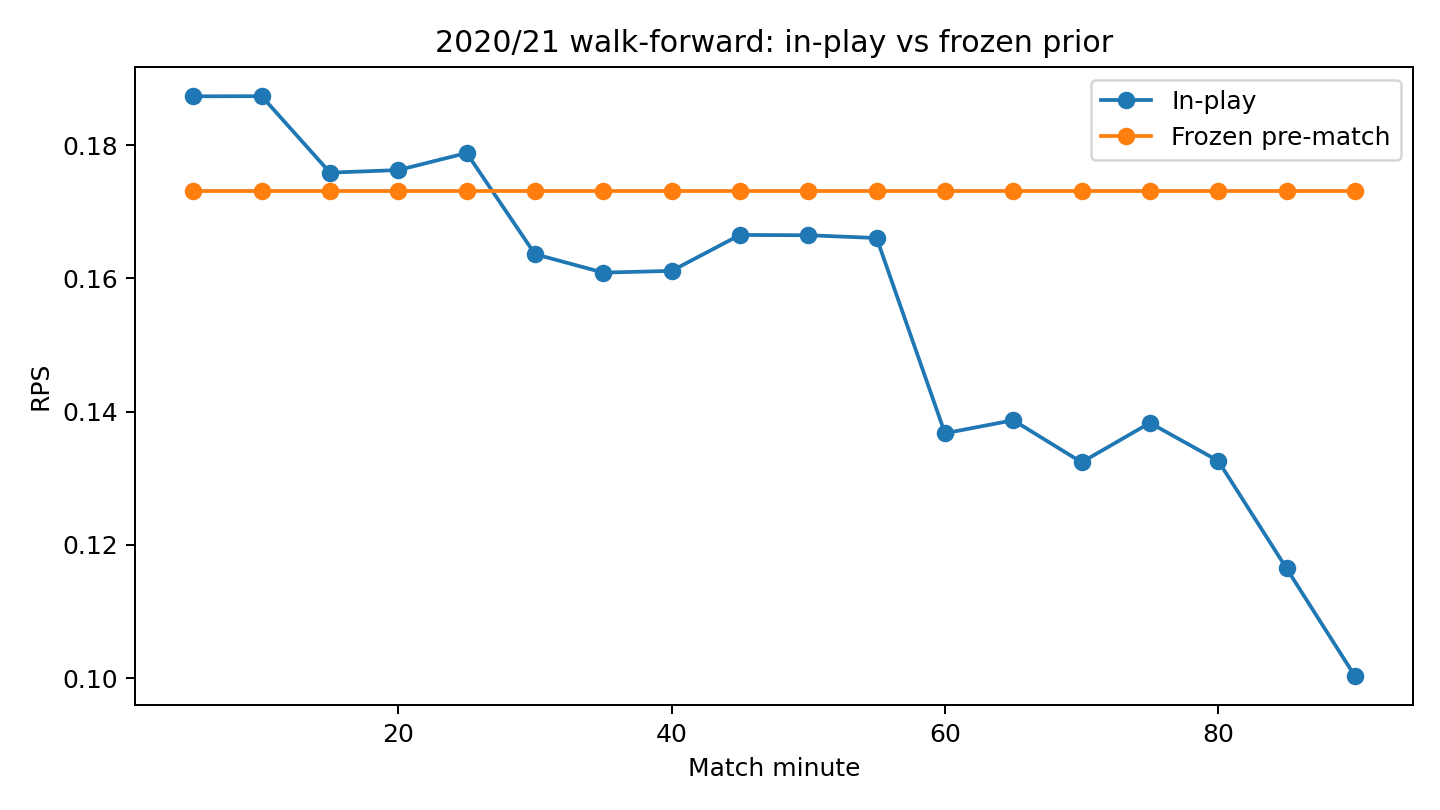

In [8]:
display(result["live_ablation"].round(4))
minutes = result["minute"]
display(minutes[minutes["snapshot_minute"].isin([5,15,30,45,60,75,90])].round(4))
display(Image(filename=str(ROOT / "phase2" / "outputs" / "inplay_rps_vs_minute_final.png")))

## 7. FIGS — show the interpretable model, do not just name it

In [9]:
display(result["figs"].round(4))
rules = (ROOT / "phase2" / "outputs" / "figs_rules_final.txt").read_text(encoding="utf-8").splitlines()
print("Actual FIGS rules from the fitted model:")
for rule in rules: print(rule)

,n_splits,n_rules,accuracy,balanced_accuracy,rps,log_loss,ece
0,7,10,0.5758,0.5324,0.2111,0.9884,0.2079


Actual FIGS rules from the fitted model:
Class=A | IF diff_form5_carries_final_third_final <= -31.95 AND diff_form5_goals_against_final <= 1 THEN contribution=-0.135589
Class=A | IF diff_form5_carries_final_third_final <= -31.95 AND diff_form5_goals_against_final > 1 THEN contribution=0.292983
Class=A | IF diff_form5_carries_final_third_final > -31.95 AND diff_form5_pressures_final <= -82 THEN contribution=-0.116262
Class=A | IF diff_form5_carries_final_third_final > -31.95 AND diff_form5_pressures_final > -82 THEN contribution=-0.241262
Class=D | IF diff_form5_carries_final_third_final <= -31.95 THEN contribution=-0.015948
Class=D | IF diff_form5_carries_final_third_final > -31.95 AND diff_form5_pressures_final <= -82 THEN contribution=0.240897
Class=D | IF diff_form5_carries_final_third_final > -31.95 AND diff_form5_pressures_final > -82 THEN contribution=-0.187823
Class=H | IF diff_form5_carries_final_third_final <= -31.95 THEN contribution=-0.195966
Class=H | IF diff_form5_carries_

## 8. Defense-ready headline numbers

In [10]:
final = result["final_summary"].set_index("system")
model_row = final.iloc[0]
market_row = final.loc["de-vigged market"]
print(f"Pre-match RPS: {model_row.rps:.4f} vs market {market_row.rps:.4f} (delta={model_row.rps-market_row.rps:+.4f})")
print(f"Pre-match ECE: {model_row.ece:.4f} vs market {market_row.ece:.4f}")
m90 = minutes.loc[minutes.snapshot_minute.eq(90)].iloc[0]
print(f"Minute 90 in-play RPS: {m90.inplay_rps:.4f} vs frozen {m90.frozen_rps:.4f}")
print(f"Minute 90 margin MAE: {m90.inplay_mae:.3f} vs frozen {m90.frozen_mae:.3f}")

Pre-match RPS: 0.1732 vs market 0.1848 (delta=-0.0116)
Pre-match ECE: 0.1207 vs market 0.1585
Minute 90 in-play RPS: 0.1003 vs frozen 0.1732
Minute 90 margin MAE: 0.905 vs frozen 1.566


In [11]:
print("PHASE2_OK")

PHASE2_OK
